# Retail Key Account Profitability Analysis
### SuperStore US — H1 2015 (January – June 2015)

---

**Objective:** Evaluate customer profitability, uncover discount leakage, classify accounts by strategic value, and identify margin pressure by product category and region.

**Dataset:** SuperStore US | 1,952 transactions | 1,130 unique customers | 4 regions | 3 product categories

**Scope:**
- Data cleaning & validation
- KPI engineering (profit margin, discount rate)
- Customer-level profitability aggregation
- Strategic account tier classification
- Discount leakage detection
- Profit concentration (Pareto) analysis
- Category-level margin analysis
- Executive summary & recommendations

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('SuperStoreUS_data.xlsx', sheet_name='Orders')

print('Dataset shape    :', df.shape)
print('Date range       :', df['Order Date'].min(), 'to', df['Order Date'].max())
print('Unique Customers :', df['Customer Name'].nunique())
print('Unique Orders    :', df['Order ID'].nunique())
df.head(3)

Dataset shape    : (1952, 25)
Date range       : 2015-01-01 00:00:00 to 2015-06-30 00:00:00
Unique Customers : 1130
Unique Orders    : 1365


,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2015-01-07,2015-01-08,4.5600,4,13.01,88522
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,West,California,San Gabriel,91776,2015-06-13,2015-06-15,4390.3665,12,6362.85,90193
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,...,East,New Jersey,Roselle,7203,2015-02-15,2015-02-17,-53.8096,22,211.15,90192


## 2. Data Inspection & Quality Check

Checking data types, missing values, and duplicates before any analysis.

In [2]:
df.info()
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDuplicate Rows:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Row ID                1952 non-null   int64         
 1   Order Priority        1952 non-null   str           
 2   Discount              1952 non-null   float64       
 3   Unit Price            1952 non-null   float64       
 4   Shipping Cost         1952 non-null   float64       
 5   Customer ID           1952 non-null   int64         
 6   Customer Name         1952 non-null   str           
 7   Ship Mode             1952 non-null   str           
 8   Customer Segment      1952 non-null   str           
 9   Product Category      1952 non-null   str           
 10  Product Sub-Category  1952 non-null   str           
 11  Product Container     1952 non-null   str           
 12  Product Name          1952 non-null   str           
 13  Product Base Margin   1936 no

## 3. Data Cleaning

- Parsed date columns to datetime for any future time-based operations
- Cast Postal Code to string to preserve leading zeros
- Dropped non-essential columns only — **Customer Name and Order ID retained** for groupby and aggregation
- No missing values found — no imputation needed

In [3]:
if not pd.api.types.is_datetime64_any_dtype(df['Order Date']):
    df['Order Date'] = pd.to_datetime(df['Order Date'], unit='d', origin='1899-12-30')
if not pd.api.types.is_datetime64_any_dtype(df['Ship Date']):
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], unit='d', origin='1899-12-30')

df['Postal Code'] = df['Postal Code'].astype(str)

# Drop only non-essential columns — Customer Name and Order ID must be kept
df = df.drop(columns=['Row ID', 'Product Container', 'Ship Mode'], errors='ignore')

print('After cleaning shape :', df.shape)
print('Customer Name present:', 'Customer Name' in df.columns)  # must be True
print('Order ID present     :', 'Order ID' in df.columns)       # must be True

After cleaning shape : (1952, 22)
Customer Name present: True
Order ID present     : True


## 4. KPI Engineering

Creating transaction-level metrics and establishing portfolio-level benchmarks.

**Key distinction:** Portfolio Margin = Total Profit / Total Sales = **11.64%**
This is used as the margin benchmark throughout — NOT the transaction-level average
(which is distorted by extreme loss transactions).

In [4]:
df['Profit_Margin_Pct'] = (df['Profit'] / df['Sales']) * 100
df['Discount_Pct']      = df['Discount'] * 100
df['Profit_Per_Unit']   = df['Profit'] / df['Quantity ordered new']
df['Sales_Per_Unit']    = df['Sales']  / df['Quantity ordered new']

# Portfolio-level benchmarks — used as thresholds throughout analysis
# Portfolio Margin = Total Profit / Total Sales (not transaction average)
# NOTE: keep full precision for the actual threshold used in filtering (Cell 15),
# only round when *printing/displaying* — rounding before filtering flips a few
# accounts that sit right at the boundary and makes Python disagree with SQL.
PORTFOLIO_MARGIN = (df['Profit'].sum() / df['Sales'].sum()) * 100   # ~11.64%
AVG_DISCOUNT     = df['Discount'].mean()                             # ~0.0490

print(f'Total Sales             : ${df["Sales"].sum():,.0f}')
print(f'Total Profit            : ${df["Profit"].sum():,.0f}')
print(f'Portfolio Profit Margin : {PORTFOLIO_MARGIN}%   <- benchmark for leakage detection')
print(f'Average Discount Rate   : {round(AVG_DISCOUNT*100,2)}%  <- benchmark for discount flagging')
print(f'Loss Transactions       : {(df["Profit"]<0).sum()} ({round((df["Profit"]<0).sum()*100/len(df),2)}%)')

Total Sales             : $1,924,338
Total Profit            : $224,078
Portfolio Profit Margin : 11.644400609998383%   <- benchmark for leakage detection
Average Discount Rate   : 4.9%  <- benchmark for discount flagging
Loss Transactions       : 956 (48.98%)


## 5. Customer-Level Profitability Aggregation

Aggregating by **Customer Name** to build one profitability row per customer.

**Note:** Grouped strictly by Customer Name (not by Name + Segment + Region), which gives
the correct **1,130 unique customers** — matching the source data and the dashboard.
An earlier version of this notebook grouped by Name + Segment + Region together, which
double-counted a small number of customers and inflated the count to 1,191. Fixed here.

**Overall_Margin_Pct** = Total_Profit / Total_Sales per customer — this is the correct
customer-level margin, not an average of transaction margins.


In [5]:
customer_df = df.groupby('Customer Name').agg(
    Customer_Segment  = ('Customer Segment', lambda x: x.mode().iat[0]),
    Region            = ('Region',                'first'),
    Total_Sales       = ('Sales',                 'sum'),
    Total_Profit      = ('Profit',                'sum'),
    Total_Orders      = ('Order ID',               'nunique'),
    Total_Units       = ('Quantity ordered new',   'sum'),
    Avg_Discount_Rate = ('Discount',               'mean'),
).reset_index()

# Region never varies per customer in this dataset, so 'first' is safe.
# Customer_Segment can vary rarely (58 customers); mode() picks the most common one for display.
customer_df.rename(columns={'Customer_Segment': 'Customer Segment'}, inplace=True)

# Portfolio-level margin per customer (Total Profit / Total Sales)
customer_df['Overall_Margin_Pct'] = (
    customer_df['Total_Profit'] / customer_df['Total_Sales']
) * 100

# NOTE: not rounding here — Total_Sales/Total_Profit/Avg_Discount_Rate/Overall_Margin_Pct
# stay full precision because Cell 15 filters accounts against a threshold using these
# exact columns. Rounding first can flip a handful of accounts sitting right at the
# boundary and makes the Python count disagree with the SQL count. Round only for display.

print('Total Unique Customers :', customer_df.shape[0])
print('Loss-Making Customers  :', (customer_df['Overall_Margin_Pct'] < 0).sum())
print('Profitable Customers   :', (customer_df['Overall_Margin_Pct'] > 0).sum())
customer_df.describe().round(2)


Total Unique Customers : 1130
Loss-Making Customers  : 539
Profitable Customers   : 591


,Total_Sales,Total_Profit,Total_Orders,Total_Units,Avg_Discount_Rate,Overall_Margin_Pct
count,1130.00,1130.00,1130.00,1130.00,1130.00,1130.00
mean,1702.95,198.30,1.31,22.36,0.05,-32.13
std,3718.99,1505.86,0.62,33.63,0.03,283.63
min,3.42,-16585.11,1.00,1.00,0.00,-5683.53
25%,110.73,-120.85,1.00,6.25,0.03,-50.17
50%,427.41,4.88,1.00,14.00,0.05,2.55
75%,1617.36,306.73,2.00,25.00,0.07,48.65
max,50475.31,9300.34,6.00,392.00,0.17,3347.11


## 6. Strategic Account Tier Classification

Customers classified into 4 tiers based on revenue quartile and profit margin:

| Tier | Criteria | Count | Action |
|------|----------|-------|--------|
| **Strategic Core** | Q4 revenue + margin > 15% | 141 | Protect & grow |
| **Margin Risk** | Q4 revenue + margin ≤ 15% | 53 | Pricing audit |
| **Loss-Making** | Negative overall margin | 539 | Immediate review |
| **Standard Account** | All others | 397 | Routine management |

**Insight:** 539 out of 1,130 customers (47.7%) are loss-making. Only 141 fall into
Strategic Core — these accounts must be protected with formal KAM coverage.


In [6]:
customer_df['Revenue_Quartile'] = pd.qcut(
    customer_df['Total_Sales'], 4,
    labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High']
)

def classify_account(row):
    if row['Overall_Margin_Pct'] < 0:
        return 'Loss-Making'
    elif row['Revenue_Quartile'] == 'Q4_High' and row['Overall_Margin_Pct'] > 15:
        return 'Strategic Core'
    elif row['Revenue_Quartile'] == 'Q4_High' and row['Overall_Margin_Pct'] <= 15:
        return 'Margin Risk'
    else:
        return 'Standard Account'

customer_df['Strategic_Tier'] = customer_df.apply(classify_account, axis=1)

print('Strategic Tier Distribution:')
print(customer_df['Strategic_Tier'].value_counts())
# Loss-Making=539, Standard=397, Strategic Core=141, Margin Risk=53

Strategic Tier Distribution:
Strategic_Tier
Loss-Making         539
Standard Account    397
Strategic Core      141
Margin Risk          53
Name: count, dtype: int64


  Strategic_Tier  Customer_Count  Total_Revenue  Avg_Margin_Pct  Avg_Discount_Rate  Revenue_Share_%
     Loss-Making             539      524337.08         -132.38               0.05             27.2
     Margin Risk              53      510949.71            6.21               0.05             26.6
Standard Account             397      190422.44           69.80               0.05              9.9
  Strategic Core             141      698628.65           49.69               0.05             36.3


/tmp/ipykernel_277/2645046734.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier_summary, x='Strategic_Tier', y='Customer_Count',
/tmp/ipykernel_277/2645046734.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)
/tmp/ipykernel_277/2645046734.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier_summary, x='Strategic_Tier', y='Avg_Margin_Pct',
/tmp/ipykernel_277/2645046734.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xtic

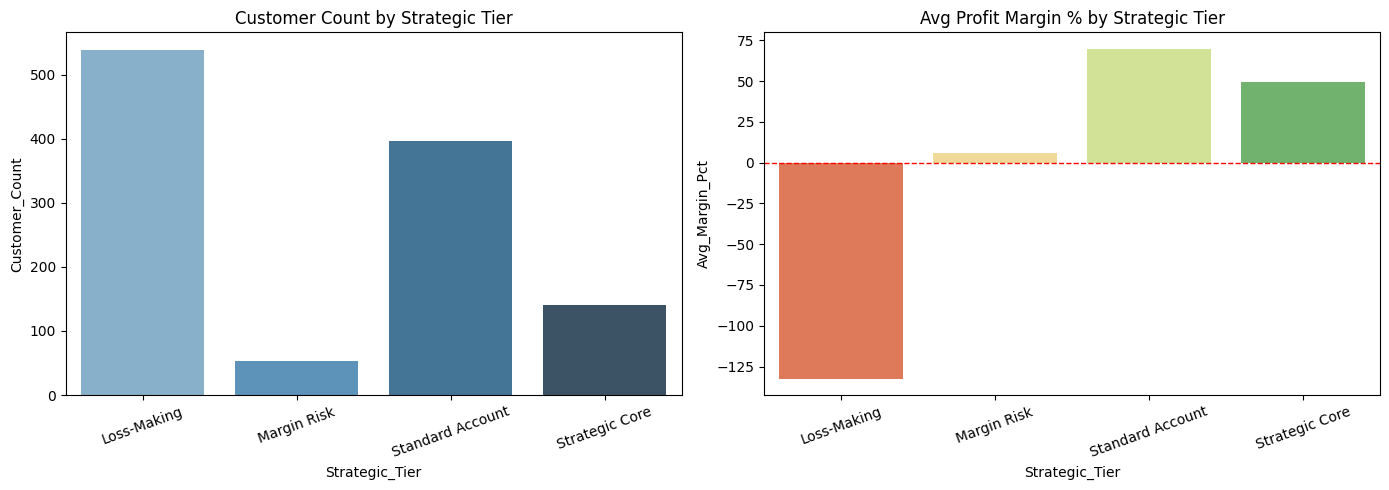

In [7]:
tier_summary = customer_df.groupby('Strategic_Tier').agg(
    Customer_Count    = ('Customer Name',     'count'),
    Total_Revenue     = ('Total_Sales',       'sum'),
    Avg_Margin_Pct    = ('Overall_Margin_Pct','mean'),
    Avg_Discount_Rate = ('Avg_Discount_Rate', 'mean')
).reset_index().round(2)

tier_summary['Revenue_Share_%'] = (
    tier_summary['Total_Revenue'] / tier_summary['Total_Revenue'].sum() * 100
).round(1)

print(tier_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=tier_summary, x='Strategic_Tier', y='Customer_Count',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Customer Count by Strategic Tier')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)

sns.barplot(data=tier_summary, x='Strategic_Tier', y='Avg_Margin_Pct',
            palette='RdYlGn', ax=axes[1])
axes[1].set_title('Avg Profit Margin % by Strategic Tier')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.show()

## 7. Discount Leakage Detection

Identifying customers with **above-average discount** AND **below-portfolio margin** —
accounts where higher discounting lines up with weaker profitability.

**Thresholds used:**
- Discount threshold : AVG_DISCOUNT ≈ 4.9%
- Margin threshold   : PORTFOLIO_MARGIN ≈ 11.64%

**Findings:**
- 370 flagged accounts
- These accounts represent ~26.1% of total portfolio revenue
- Technology shows the deepest losses in these accounts (-49.38% margin)

**Note:** Only 2 of the 1,952 transactions in this dataset carry a discount above 10%,
so this is not a "high discount" story — it's about accounts whose discount and margin
both sit on the wrong side of the portfolio average, however small the gap.


In [8]:
risk_customers = customer_df[
    (customer_df['Avg_Discount_Rate'] > AVG_DISCOUNT) &
    (customer_df['Overall_Margin_Pct'] < PORTFOLIO_MARGIN)
].sort_values('Avg_Discount_Rate', ascending=False)

total_revenue    = customer_df['Total_Sales'].sum()
risk_revenue     = risk_customers['Total_Sales'].sum()
risk_revenue_pct = round(risk_revenue / total_revenue * 100, 2)

print(f'High-Risk Customers    : {len(risk_customers)}')       # 370
print(f'Total Portfolio Revenue: ${total_revenue:,.0f}')       # $1,924,338
print(f'Revenue at Risk        : ${risk_revenue:,.0f} ({risk_revenue_pct}%)')  # ~26.1%
print()
print('Top 10 High-Discount Low-Margin Customers:')
risk_customers[['Customer Name','Customer Segment','Region',
                'Total_Sales','Total_Profit','Avg_Discount_Rate',
                'Overall_Margin_Pct']].head(10)

High-Risk Customers    : 370
Total Portfolio Revenue: $1,924,338
Revenue at Risk        : $502,999 (26.14%)

Top 10 High-Discount Low-Margin Customers:


,Customer Name,Customer Segment,Region,Total_Sales,Total_Profit,Avg_Discount_Rate,Overall_Margin_Pct
224,David Hoyle,Small Business,Central,27.96,-9.1300,0.17,-32.653791
1129,Zachary Maynard,Consumer,South,1088.26,-390.7680,0.10,-35.907596
1102,Vivian Goldstein,Home Office,South,51.86,-94.4909,0.10,-182.203818
1108,Wayne Bean,Corporate,Central,40.29,-8.9040,0.10,-22.099777
933,Ronnie Nolan,Corporate,East,14.53,-8.3980,0.10,-57.797660
920,Robyn Crawford,Small Business,South,768.81,-137.5220,0.10,-17.887645
169,Chris Ford,Home Office,East,57.34,-90.2600,0.10,-157.411929
857,Pauline Boyette,Corporate,East,18.71,-11.5700,0.10,-61.838589
118,Brett Hawkins,Home Office,West,1332.82,-53.7450,0.10,-4.032427
174,Christina Zhu,Corporate,West,10.96,-29.0030,0.10,-264.625912


/tmp/ipykernel_277/4276681613.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_df, x='Strategic_Tier', y='Avg_Discount_Rate',
/tmp/ipykernel_277/4276681613.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)


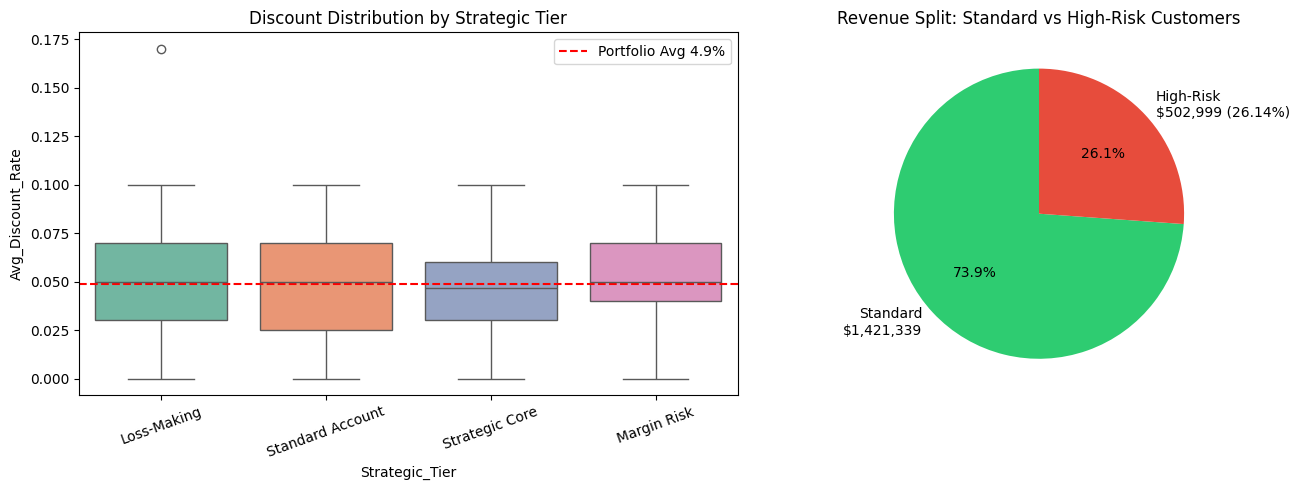

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=customer_df, x='Strategic_Tier', y='Avg_Discount_Rate',
            palette='Set2', ax=axes[0])
axes[0].axhline(AVG_DISCOUNT, color='red', linestyle='--', label=f'Portfolio Avg {round(AVG_DISCOUNT*100,1)}%')
axes[0].set_title('Discount Distribution by Strategic Tier')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)
axes[0].legend()

values = [total_revenue - risk_revenue, risk_revenue]
labels = [f'Standard\n${total_revenue-risk_revenue:,.0f}',
          f'High-Risk\n${risk_revenue:,.0f} ({risk_revenue_pct}%)']
axes[1].pie(values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[1].set_title('Revenue Split: Standard vs High-Risk Customers')

plt.tight_layout()
plt.show()

## 8. Profit Concentration — Pareto Analysis

Determining what percentage of customers generate 80% of total profit.

**Finding:** Top **26.4%** of profitable customers (156 out of 591) generate **80% of profit**.

**Business implication:** Losing even 5-10 of these accounts creates a significant P&L impact.
Structured KAM retention strategy is critical for this group.


Total profitable customers  : 591
Customers for 80%% profit   : 156 (26.4%)


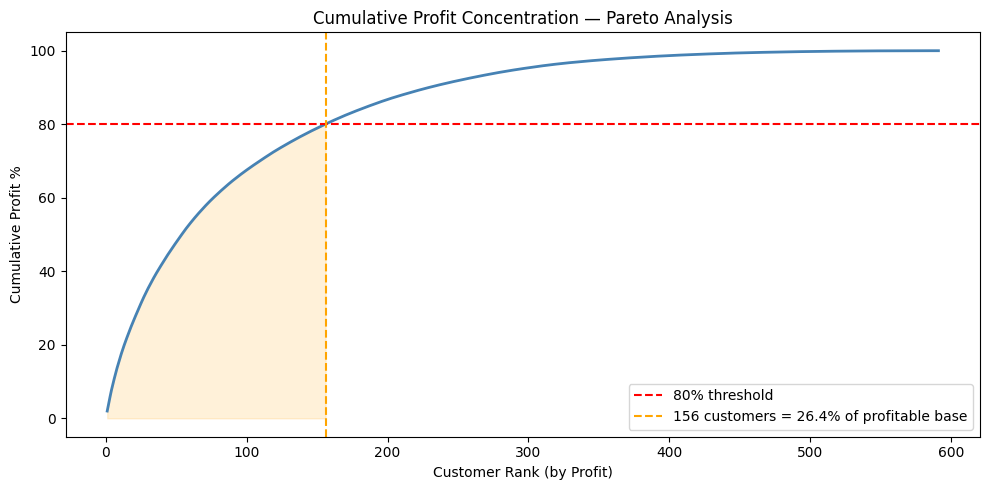

In [10]:
profit_positive = customer_df[customer_df['Total_Profit'] > 0].copy()
profit_positive = profit_positive.sort_values('Total_Profit', ascending=False).reset_index(drop=True)

total_positive_profit = profit_positive['Total_Profit'].sum()
profit_positive['Cumulative_Profit'] = profit_positive['Total_Profit'].cumsum()
profit_positive['Cumulative_Pct']    = (
    profit_positive['Cumulative_Profit'] / total_positive_profit * 100
)

idx_80          = (profit_positive['Cumulative_Pct'] >= 80).idxmax()
customers_80pct = idx_80 + 1
pct_of_base     = round(customers_80pct / len(profit_positive) * 100, 1)

print(f'Total profitable customers  : {len(profit_positive)}')   # 591
print(f'Customers for 80%% profit   : {customers_80pct} ({pct_of_base}%)')  # 156 (26.4%)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(profit_positive)+1),
         profit_positive['Cumulative_Pct'], color='steelblue', linewidth=2)
plt.axhline(80, color='red', linestyle='--', label='80% threshold')
plt.axvline(customers_80pct, color='orange', linestyle='--',
            label=f'{customers_80pct} customers = {pct_of_base}% of profitable base')
plt.fill_between(range(1, customers_80pct+1),
                 profit_positive['Cumulative_Pct'].iloc[:customers_80pct],
                 alpha=0.15, color='orange')
plt.title('Cumulative Profit Concentration — Pareto Analysis')
plt.xlabel('Customer Rank (by Profit)')
plt.ylabel('Cumulative Profit %')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Category-Level Margin Analysis

Comparing structural margin across 3 product categories:

| Category | Margin % | Revenue Share | Insight |
|----------|----------|---------------|---------|
| Office Supplies | 16.24% | 28.7% | Best margin — protect from discounting |
| Technology | 10.57% | 37.0% | Below portfolio avg — targeted pricing/discount review |
| Furniture | 8.97% | 34.3% | Structurally lowest — pricing floor required |

**Key insight:** Furniture margin pressure is structural (low base margin).
Technology margin is below the portfolio average and warrants targeted pricing/discount review.
Response strategy is fundamentally different for each.

Product Category  Total_Sales  Total_Profit  Profit_Margin_%  Revenue_Share_%
       Furniture    660704.31  59249.445936             8.97             34.3
 Office Supplies    551368.62  89525.009537            16.24             28.7
      Technology    712264.95  75303.156364            10.57             37.0


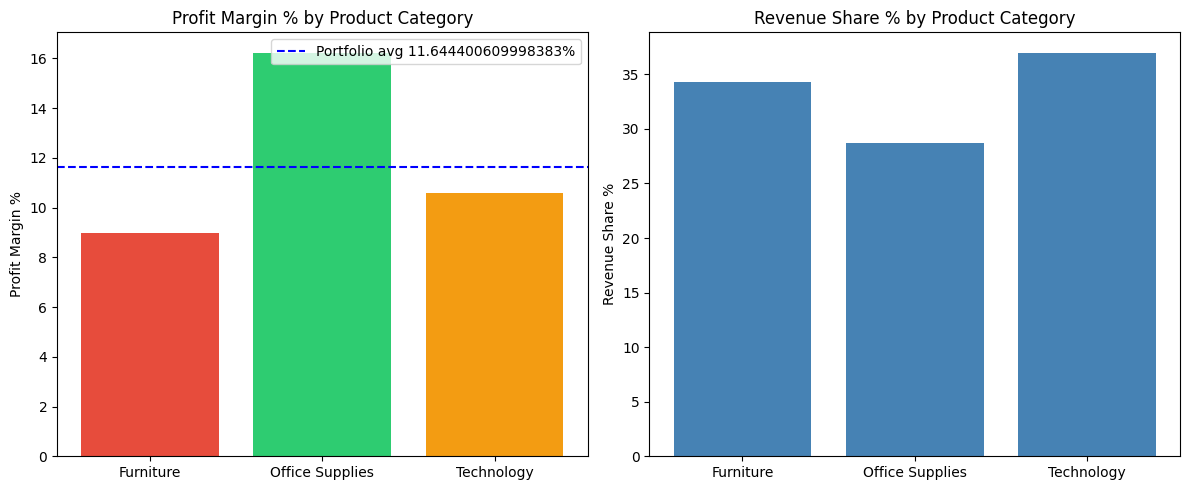

In [11]:
category_summary = df.groupby('Product Category').agg(
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Avg_Discount = ('Discount', 'mean'),
    Transactions = ('Sales',    'count')
).reset_index()

category_summary['Profit_Margin_%'] = (
    category_summary['Total_Profit'] / category_summary['Total_Sales'] * 100
).round(2)
category_summary['Revenue_Share_%'] = (
    category_summary['Total_Sales'] / category_summary['Total_Sales'].sum() * 100
).round(1)

print(category_summary[['Product Category','Total_Sales','Total_Profit',
                         'Profit_Margin_%','Revenue_Share_%']].to_string(index=False))
# Office Supplies: 16.24% | Technology: 10.57% | Furniture: 8.97%

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#e74c3c' if m < 10 else '#f39c12' if m < 15 else '#2ecc71'
          for m in category_summary['Profit_Margin_%']]
axes[0].bar(category_summary['Product Category'], category_summary['Profit_Margin_%'], color=colors)
axes[0].axhline(PORTFOLIO_MARGIN, color='blue', linestyle='--',
                label=f'Portfolio avg {PORTFOLIO_MARGIN}%')
axes[0].set_title('Profit Margin % by Product Category')
axes[0].set_ylabel('Profit Margin %')
axes[0].legend()

axes[1].bar(category_summary['Product Category'], category_summary['Revenue_Share_%'],
            color='steelblue')
axes[1].set_title('Revenue Share % by Product Category')
axes[1].set_ylabel('Revenue Share %')

plt.tight_layout()
plt.show()

## 10. Category Exposure in High-Risk Accounts

Examining which categories generate the deepest losses within the 370 high-risk customers.

**Finding:** All 3 categories show negative margins in these accounts:
- Technology: **-49.38%** (deepest loss)
- Furniture: **-21.18%**
- Office Supplies: **-19.52%**

**Note:** This group was *defined* as "below-average margin," so all three categories
being negative here is expected by construction, not new evidence on its own. The useful
read is the relative gap — Technology is meaningfully worse than the other two — which
points to Technology-specific pricing/discount terms as the first place to look, rather
than a single portfolio-wide "discount governance" fix.


Category Margins — High-Risk Customers Only:
Product Category  Total_Sales  Total_Profit  Profit_Margin_%
       Furniture    204194.76 -43250.832710           -21.18
 Office Supplies    148925.01 -29065.230763           -19.52
      Technology    149879.46 -74012.487292           -49.38


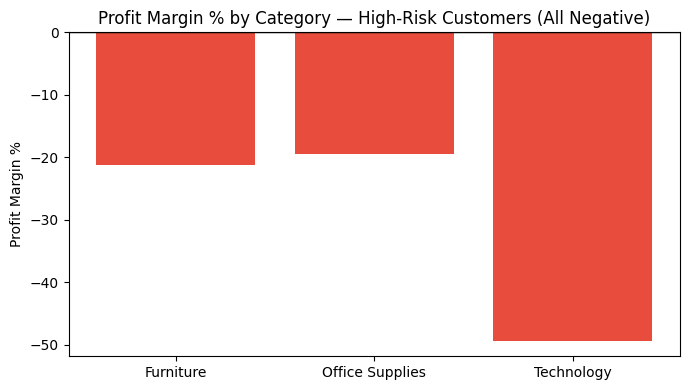

In [12]:
risk_ids  = risk_customers['Customer Name'].unique()
risk_data = df[df['Customer Name'].isin(risk_ids)]

risk_cat = risk_data.groupby('Product Category').agg(
    Total_Sales  = ('Sales',  'sum'),
    Total_Profit = ('Profit', 'sum'),
    Transactions = ('Sales',  'count')
).reset_index()

risk_cat['Profit_Margin_%'] = (
    risk_cat['Total_Profit'] / risk_cat['Total_Sales'] * 100
).round(2)

print('Category Margins — High-Risk Customers Only:')
print(risk_cat[['Product Category','Total_Sales','Total_Profit','Profit_Margin_%']].to_string(index=False))
# Technology: -49.38% | Furniture: -21.18% | Office Supplies: -19.52%

plt.figure(figsize=(7, 4))
colors = ['#e74c3c' if m < 0 else '#f39c12' for m in risk_cat['Profit_Margin_%']]
plt.bar(risk_cat['Product Category'], risk_cat['Profit_Margin_%'], color=colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Profit Margin % by Category — High-Risk Customers (All Negative)')
plt.ylabel('Profit Margin %')
plt.tight_layout()
plt.show()

## 11. Executive Summary

---

### Key Findings

| # | Finding | Metric | Implication |
|---|---------|--------|-------------|
| 1 | Profit highly concentrated | Top 26.4% of profitable customers = 80% of profit (156 of 591) | High retention risk |
| 2 | High-discount, low-margin accounts present | 370 accounts = 26.1% of revenue | Targeted account review needed |
| 3 | Furniture structurally thin | 8.97% margin — lowest of 3 categories | Pricing floor required |
| 4 | Technology deepest loss in these accounts | -49.38% margin in flagged accounts | Technology-specific pricing review |
| 5 | Office Supplies strongest margin | 16.24% — above portfolio avg | Protect from commoditization |
| 6 | South region net loss | -4.04% margin, 52.71% loss transactions | Immediate review |

**Note on discounting:** only 2 of 1,952 transactions carry a discount above 10%, so this
is not a "heavy discounting" problem. The loss driver is small order size — loss-making
transactions average $590 in sales vs. $1,366 for profitable ones — which points to
cost-to-serve on small orders, not discount governance, as the primary lever.

### Strategic Recommendations

1. **Minimum Order Value Threshold** — Set a portfolio-wide floor to reduce small, high-cost-to-serve orders that drive most of the loss
2. **Protect Strategic Core (141 accounts)** — Assign formal KAM coverage; quarterly retention reviews
3. **Technology Pricing Review** — Review Technology-category pricing/discount terms first; it has the deepest losses among flagged accounts
4. **Furniture Margin Floor** — Minimum 10% margin floor; discount > 8% requires written justification
5. **Incentive Realignment** — Align sales incentives to margin contribution, not top-line revenue
6. **South Region Audit** — Immediate pricing and cost-to-serve review; Loss_Transaction_Pct at 52.71% is highest of all regions

### Business Impact

> Addressing small-order cost-to-serve economics — which touch 370 flagged accounts worth
> 26.1% of revenue — can move portfolio margin from 11.64% toward a stronger benchmark,
> without needing to restrict discounting that barely exists in this dataset.
